# Functional Connectivity Analysis — Random Model Demo

**Contents**
1. Thesis plot style configuration
2. Simulated signal: *random* model — ground truth & time series
3. Functional connectivity computation (ADTF, PDCoh, DTF, cGC, PLI, PSI)
4. Connectivity matrix grid (thesis-quality)
5. Export figures as PDF + PNG

## 0. Setup & Thesis Style

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from simulation.simulation_models import simulate
from methods.fc_pipeline import FCMethods
from sklearn.metrics import matthews_corrcoef

# ── Figure style ──────────────────────────────────────────────────────────────
FIGURE_STYLE = {
    # Font
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 11,
    # Axes
    'axes.titlesize'     : 12,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 11,
    'axes.linewidth'     : 0.8,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    # Ticks
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'xtick.major.width'  : 0.8,
    'ytick.major.width'  : 0.8,
    # Legend
    'legend.fontsize'    : 9,
    'legend.frameon'     : False,
    # Figure
    'figure.dpi'         : 120,
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
    # Lines
    'lines.linewidth'    : 1.2,
}
mpl.rcParams.update(FIGURE_STYLE)

# ── Output folder ─────────────────────────────────────────────────────────────
FIG_DIR = os.path.join('..', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    """Save current figure as both PDF (vector) and PNG (raster)."""
    for ext in ('pdf', 'png'):
        path = os.path.join(FIG_DIR, f'{name}.{ext}')
        plt.savefig(path)
    print(f'Saved → figures/{name}.pdf / .png')

print('Style configured. Output directory:', os.path.abspath(FIG_DIR))

Style configured. Output directory: c:\Users\viola\Documents\UKW\INF\Causality-Analysis-main\Causality-Analysis\figures


## 1. Simulated Data — Random Model

The **random** model is a 5-node linear system with fixed causal delays:

| Connection | Delay |
|---|---|
| x₁ → x₂ | 3 samples |
| x₁ → x₃ | 2 samples |
| x₄ → x₅ | 5 samples |

Nodes x₁ and x₄ are independent noise sources.

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
MODEL   = 'random'
T       = 1000          # time points
FS      = 256           # Hz
N_NODES = 5
SEED    = 42
NODE_LABELS = [f'x{i+1}' for i in range(N_NODES)]

# ── Ground truth adjacency (source → target) ──────────────────────────────────
GT = np.array([
    [0, 1, 1, 0, 0],   # x1 → x2, x3
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1],   # x4 → x5
    [0, 0, 0, 0, 0],
])

# ── Generate 5 epochs → stack to (epochs, nodes, time) ────────────────────────
N_EPOCHS = 10
epochs = np.stack(
    [simulate(MODEL, T=T, seed=SEED + e) for e in range(N_EPOCHS)],
    axis=0
)  # shape: (10, 5, 1000)

signal = epochs[0]    # single epoch for visualization
print(f'Data shape (epochs, nodes, time): {epochs.shape}')
print(f'Signal range: [{signal.min():.2f}, {signal.max():.2f}]')

Data shape (epochs, nodes, time): (10, 5, 1000)
Signal range: [-3.40, 3.92]


### 1.1 Ground Truth

Saved → figures/fig1_ground_truth.pdf / .png


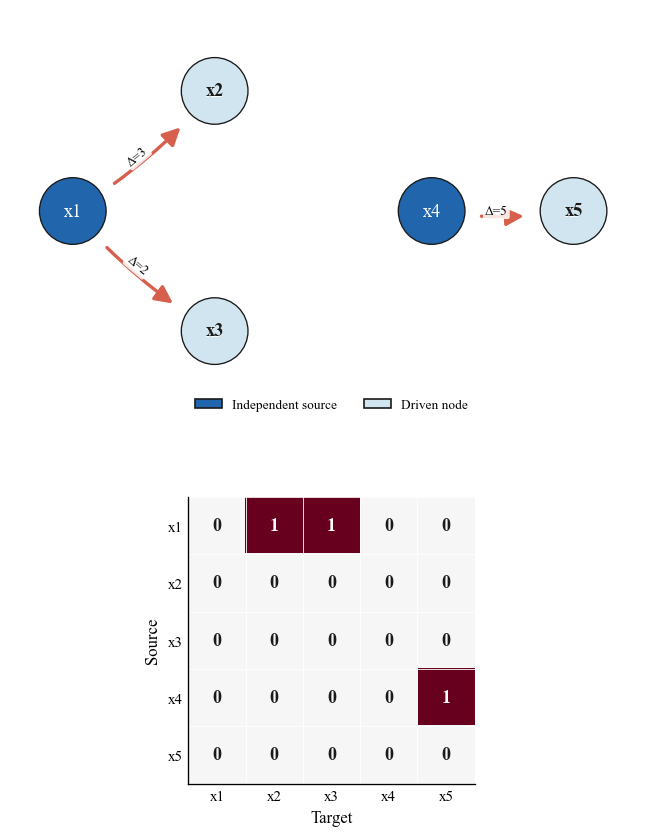

In [ ]:
fig = plt.figure(figsize=(7.0, 8.5))
gs  = fig.add_gridspec(2, 1, hspace=0.25, height_ratios=[1.3, 1.0])

# ── (a) Directed connectivity graph ───────────────────────────────────────────
ax_g = fig.add_subplot(gs[0])

G = nx.DiGraph()
G.add_nodes_from(range(N_NODES))
edges = [(i, j) for i in range(N_NODES) for j in range(N_NODES) if GT[i, j]]
G.add_edges_from(edges)

pos = {
    0: (0.5, 1.0),   # x1 (source)
    1: (2.2, 1.7),   # x2
    2: (2.2, 0.3),   # x3
    3: (4.8, 1.0),   # x4 (source)
    4: (6.5, 1.0),   # x5
}

SOURCE_NODES = [0, 3]
node_colors  = ['#2166ac' if n in SOURCE_NODES else '#d1e5f0' for n in G.nodes]

nx.draw_networkx_nodes(G, pos, ax=ax_g,
                       node_size=1600, node_color=node_colors,
                       edgecolors='#1a1a1a', linewidths=0.8)
nx.draw_networkx_labels(G, pos, ax=ax_g,
                        labels={i: NODE_LABELS[i] for i in G.nodes},
                        font_size=11, font_family='serif', font_color='white')
for node, (x, y) in pos.items():
    if node not in SOURCE_NODES:
        ax_g.text(x, y, NODE_LABELS[node], ha='center', va='center',
                  fontsize=11, fontfamily='serif', color='#1a1a1a',
                  fontweight='bold', zorder=5)

nx.draw_networkx_edges(G, pos, ax=ax_g,
                       edge_color='#d6604d', width=2.0,
                       arrows=True, arrowstyle='-|>', arrowsize=22,
                       connectionstyle='arc3,rad=0.08',
                       min_source_margin=30, min_target_margin=30)

edge_labels = {(0, 1): 'Δ=3', (0, 2): 'Δ=2', (3, 4): 'Δ=5'}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax_g,
                              font_size=8, font_family='serif', label_pos=0.45,
                              bbox=dict(boxstyle='round,pad=0.15',
                                        fc='white', ec='none', alpha=0.85))

legend_elements = [
    mpatches.Patch(facecolor='#2166ac', edgecolor='#1a1a1a', label='Independent source'),
    mpatches.Patch(facecolor='#d1e5f0', edgecolor='#1a1a1a', label='Driven node'),
]
ax_g.legend(handles=legend_elements, loc='lower center',
            bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=8)
# ax_g.set_title('Ground Truth Connectivity', fontsize=12, fontweight='bold', pad=10)
ax_g.axis('off')
ax_g.set_xlim(-0.3, 7.5)
ax_g.set_ylim(-0.1, 2.2)

# ── (b) Adjacency matrix — centred using inset axes ───────────────────────────
ax_bg = fig.add_subplot(gs[1])
ax_bg.axis('off')

# Inset centred at 35% offset, 30% wide (fits a square 5×5 matrix)
ax_m = ax_bg.inset_axes([0.28, 0.02, 0.44, 0.95])

im = ax_m.imshow(GT.astype(float), cmap='RdBu_r', vmin=-1, vmax=1,
                 aspect='equal', interpolation='nearest')

for r in range(N_NODES):
    for c in range(N_NODES):
        col = 'white' if GT[r, c] == 1 else '#1a1a1a'
        ax_m.text(c, r, str(int(GT[r, c])), ha='center', va='center',
                  fontsize=11, fontfamily='serif', fontweight='bold', color=col)

ax_m.set_xticks(range(N_NODES)); ax_m.set_xticklabels(NODE_LABELS, fontsize=9)
ax_m.set_yticks(range(N_NODES)); ax_m.set_yticklabels(NODE_LABELS, fontsize=9, rotation=0)
for k in np.arange(-0.5, N_NODES, 1):
    ax_m.axhline(k, color='white', linewidth=0.5)
    ax_m.axvline(k, color='white', linewidth=0.5)
ax_m.tick_params(length=0)
ax_m.set_xlabel('Target', fontsize=10)
ax_m.set_ylabel('Source', fontsize=10)
# ax_m.set_title('Ground Truth Adjacency', fontsize=12, fontweight='bold', pad=10)

# cbar = plt.colorbar(im, ax=ax_m, fraction=0.046, pad=0.06)
# cbar.set_ticks([-1, 0, 1])
# cbar.ax.tick_params(labelsize=8)

# fig.suptitle('Ground Truth — Random Model', fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
savefig('fig1_ground_truth')
plt.show()

### 1.2 Simulated Time Series

Saved → figures/fig2_time_series.pdf / .png


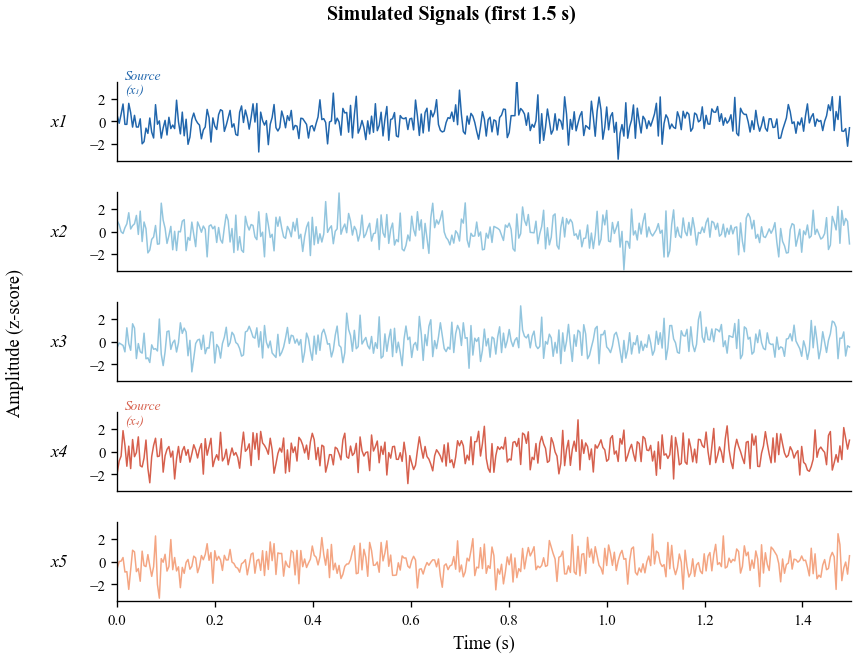

In [ ]:
t = np.arange(T) / FS   # time axis in seconds
T_SHOW = int(1.5 * FS)  # show first 1.5 s

# Colour map: driven nodes lighter, source nodes darker (same palette as graph)
NODE_COLORS = ['#2166ac', '#92c5de', '#92c5de', '#d6604d', '#f4a582']

fig, axes = plt.subplots(N_NODES, 1, figsize=(7.0, 5.5), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(t[:T_SHOW], signal[i, :T_SHOW],
            color=NODE_COLORS[i], linewidth=0.9)
    ax.set_ylabel(NODE_LABELS[i], rotation=0, labelpad=18,
                  va='center', fontsize=11, fontstyle='italic')
    ax.set_ylim(-3.5, 3.5)
    ax.set_yticks([-2, 0, 2])
    ax.tick_params(left=True, bottom=(i == N_NODES - 1))
    # Highlight causal connections with a bracket annotation on the last source
    if i == 0:
        ax.annotate('Source\n(x₁)', xy=(0.01, 0.85), xycoords='axes fraction',
                    fontsize=8, color='#2166ac', fontstyle='italic')
    if i == 3:
        ax.annotate('Source\n(x₄)', xy=(0.01, 0.85), xycoords='axes fraction',
                    fontsize=8, color='#d6604d', fontstyle='italic')

axes[-1].set_xlabel('Time (s)', fontsize=11)
axes[-1].set_xlim(0, T_SHOW / FS)


fig.text(-0.03, 0.5, 'Amplitude (z-score)', va='center', rotation='vertical',
         fontsize=11)
fig.suptitle('Simulated Signals (first 1.5 s)', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig2_time_series')
plt.show()

## 2. Functional Connectivity Computation

In [ ]:
METHODS_PARAMS = {
    'ADTF' : {'fmin': 8, 'fmax': 12, 'n_freqs': 100, 'maxlags': 10, 'integrate': True},
    'PDCoh': {'model_order': 5, 'n_fft': 128, 'ica_method': 'infomax_extended', 'integrate': True},
    'DTF'  : {'model_order': 5, 'n_fft': 128, 'ica_method': 'infomax_extended', 'integrate': True},
    'cGC'  : {},
    'PLI'  : {'fmin': 8, 'fmax': 12, 'integrate': True},
    'PSI'  : {'fmin': 8, 'fmax': 12, 'integrate': True},
}

# ── Compute ───────────────────────────────────────────────────────────────────
fc      = FCMethods(epochs, fs=FS)
results = fc.compute_all(METHODS_PARAMS)

for method, res in results.items():
    status = 'OK' if 'matrix' in res else f"ERROR: {res.get('error', '?')}"
    print(f'  {method:<8} {status}')

Computing Extended Infomax ICA
Computing Extended Infomax ICA
  ADTF     OK
  PDCoh    OK
  DTF      OK
  cGC      OK
  PLI      OK
  PSI      OK


## 3. Connectivity Matrix Grid

In [ ]:
def binarize(conn, method, percentile=75):
    """Threshold a connectivity matrix to a binary adjacency matrix.

    All FC matrices are transposed to [source, target] convention before
    thresholding, matching GT[i,j] = i→j.
    PSI already uses [source, target]; all other methods use [target, source].
    """
    m = conn.copy()
    np.fill_diagonal(m, 0)
    # Transpose to source→target convention; PSI is already correct
    if method != 'PSI':
        m = m.T
    if method == 'Corr':
        m = np.abs(m)
    off = m[~np.eye(N_NODES, dtype=bool)]
    thr = np.nanpercentile(np.abs(off), percentile)
    b = (m >= thr).astype(int)
    np.fill_diagonal(b, 0)
    return b

def mcc_score(pred, true):
    from sklearn.metrics import matthews_corrcoef
    return matthews_corrcoef(true.flatten(), pred.flatten())

In [ ]:
METHOD_LIST = list(METHODS_PARAMS.keys())   # 6 methods
N_METHODS   = len(METHOD_LIST)

# ── Layout: 2 rows × 3 cols  (6 methods, no GT panel) ────────────────────────
N_COLS = 3
N_ROWS = 2
FIG_W  = 7.0
FIG_H  = 4.2

fig, axes = plt.subplots(N_ROWS, N_COLS,
                         figsize=(FIG_W, FIG_H),
                         gridspec_kw={'hspace': 0.60, 'wspace': 0.35})
axes_flat = axes.flatten()

def maxabs_normalize(m):
    """Normalize off-diagonal to [-1, 1] by dividing by the max absolute value.
    
    Each method is scaled independently so the strongest connection = ±1.
    This keeps the sign (for cGC, PSI) while making scales comparable across
    methods with very different output ranges (e.g. ADTF ≈ 0.02, PLI ≈ 0.8).
    """
    out = m.copy()
    np.fill_diagonal(out, 0)
    mask = ~np.eye(N_NODES, dtype=bool)
    maxabs = np.nanmax(np.abs(out[mask]))
    if maxabs > 0:
        out[mask] = out[mask] / maxabs
    return out

def draw_matrix(ax, matrix, title, cmap='RdBu_r', show_cbar=False):
    im = ax.imshow(matrix, cmap=cmap, vmin=-1, vmax=1,
                   aspect='equal', interpolation='nearest')

    for r in range(N_NODES):
        for c in range(N_NODES):
            val = matrix[r, c]
            if not np.isnan(val):
                col = 'white' if abs(val) > 0.55 else '#1a1a1a'
                ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                        fontsize=6.5, color=col, fontfamily='serif')

    ax.set_xticks(range(N_NODES)); ax.set_xticklabels(NODE_LABELS, fontsize=7)
    ax.set_yticks(range(N_NODES)); ax.set_yticklabels(NODE_LABELS, fontsize=7, rotation=0)
    ax.tick_params(length=0)
    for k in np.arange(-0.5, N_NODES, 1):
        ax.axhline(k, color='white', linewidth=0.4)
        ax.axvline(k, color='white', linewidth=0.4)

    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)

    if show_cbar:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=7)
    return im

# ── 6 FC method panels ────────────────────────────────────────────────────────
for idx, method in enumerate(METHOD_LIST):
    ax  = axes_flat[idx]
    res = results[method]

    if 'matrix' not in res:
        ax.axis('off'); ax.set_title(method, fontsize=9); continue

    conn = res['matrix'].copy()
    np.fill_diagonal(conn, 0)

    # Transpose to source→target convention; PSI already correct
    if method != 'PSI':
        conn = conn.T

    # Max-abs normalize to [-1, 1] for comparable display across methods
    conn_display = maxabs_normalize(conn)

    draw_matrix(ax, conn_display, method, show_cbar=False)

# ── Shared axis labels ────────────────────────────────────────────────────────
for ax in axes[:, 0]:
    ax.set_ylabel('Source', fontsize=8, labelpad=4)
for ax in axes[-1, :]:
    ax.set_xlabel('Target', fontsize=8, labelpad=2)

# ── Shared diverging colorbar ─────────────────────────────────────────────────
plt.subplots_adjust(right=0.87)
sm = mpl.cm.ScalarMappable(cmap='RdBu_r',
                            norm=mpl.colors.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar_ax = fig.add_axes([0.895, 0.12, 0.018, 0.76])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['-1\n(min)', '0', '+1\n(max)'])
# cbar.set_label('FC strength (max-abs normalised)', fontsize=7, labelpad=6)
cbar.ax.tick_params(labelsize=7)

# fig.suptitle(
#     'Functional Connectivity Matrices — Random Model\n'
#     f'({N_EPOCHS} epochs × {T} samples,  $f_s = {FS}$ Hz)',
#     fontsize=11, fontweight='bold', y=1.02
# )
fig.suptitle(
    'Functional Connectivity Matrices',
    fontsize=11, fontweight='bold', y=1.02
)
savefig('fig4_fc_matrix_grid')
plt.show()

## 4. MCC Summary Bar Chart

Saved → figures/fig4b_mcc_bar.pdf / .png


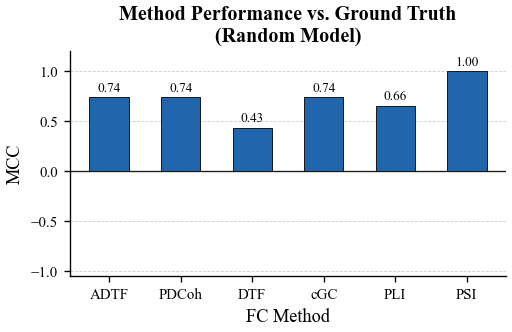

In [ ]:
mcc_scores = {}
for method in METHOD_LIST:
    res = results[method]
    if 'matrix' not in res:
        mcc_scores[method] = np.nan
        continue
    binary = binarize(res['matrix'], method, percentile=75)
    mcc_scores[method] = mcc_score(binary, GT)

methods = list(mcc_scores.keys())
values  = [mcc_scores[m] for m in methods]

bar_colors = ['#2166ac' if v >= 0 else '#d6604d' for v in values]

fig, ax = plt.subplots(figsize=(4.5, 3.0))
bars = ax.bar(methods, values, color=bar_colors, edgecolor='#1a1a1a',
              linewidth=0.6, width=0.55, zorder=3)

for bar, val in zip(bars, values):
    if not np.isnan(val):
        ypos = val + 0.03 if val >= 0 else val - 0.07
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=8, fontfamily='serif')

ax.axhline(0, color='#1a1a1a', linewidth=0.8)
ax.set_ylim(-1.05, 1.2)
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_ylabel('MCC', fontsize=11)
ax.set_xlabel('FC Method', fontsize=11)
ax.set_title('Method Performance vs. Ground Truth\n(Random Model)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', linewidth=0.5, color='#cccccc', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
savefig('fig4b_mcc_bar')
plt.show()

## 5. AUC-ROC and Average Precision

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

def get_scores(matrix, method):
    """Return continuous FC scores in [source, target] convention, diagonal zeroed."""
    m = matrix.copy()
    np.fill_diagonal(m, 0)
    if method != 'PSI':
        m = m.T          # transpose to source→target
    if method == 'Corr':
        m = np.abs(m)
    # Use absolute value as ranking score (strength of connection)
    return np.abs(m)

mask = ~np.eye(N_NODES, dtype=bool)   # off-diagonal mask
y_true = GT[mask].flatten()           # ground truth labels (0/1)

auc_roc_scores = {}
avg_prec_scores = {}

for method in METHOD_LIST:
    res = results[method]
    if 'matrix' not in res:
        auc_roc_scores[method] = np.nan
        avg_prec_scores[method] = np.nan
        continue
    scores = get_scores(res['matrix'], method)
    y_score = scores[mask].flatten()
    auc_roc_scores[method]  = roc_auc_score(y_true, y_score)
    avg_prec_scores[method] = average_precision_score(y_true, y_score)

# ── Print summary table ────────────────────────────────────────────────────────
print(f"{'Method':<10} {'AUC-ROC':>10} {'Avg Precision':>15}")
print("-" * 37)
for m in METHOD_LIST:
    print(f"{m:<10} {auc_roc_scores[m]:>10.3f} {avg_prec_scores[m]:>15.3f}")

Method        AUC-ROC   Avg Precision
-------------------------------------
ADTF            1.000           1.000
PDCoh           1.000           1.000
DTF             0.882           0.633
cGC             1.000           1.000
PLI             0.912           0.500
PSI             0.931           0.589


Saved → figures/fig5_auc_roc_avg_precision.pdf / .png


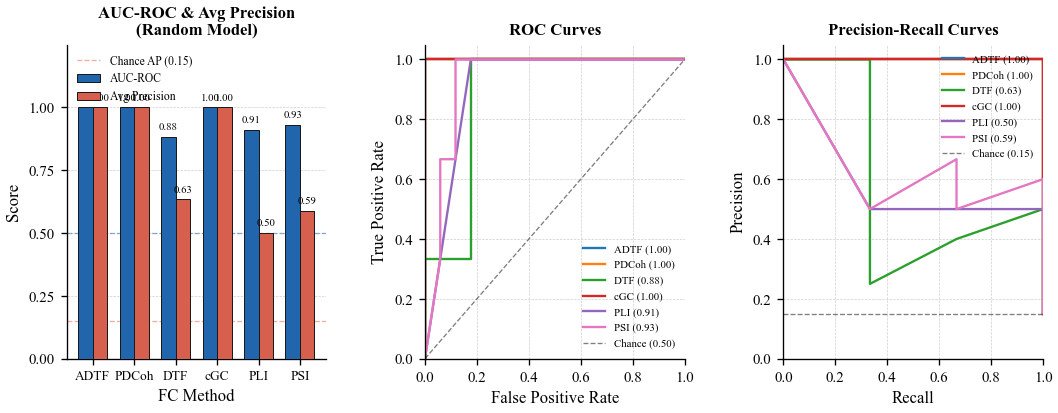

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4),
                         gridspec_kw={'wspace': 0.38})

# ── (a) Grouped bar chart ─────────────────────────────────────────────────────
ax = axes[0]
x      = np.arange(N_METHODS)
width  = 0.35
vals_auc = [auc_roc_scores[m] for m in METHOD_LIST]
vals_ap  = [avg_prec_scores[m] for m in METHOD_LIST]

bars1 = ax.bar(x - width/2, vals_auc, width, label='AUC-ROC',
               color='#2166ac', edgecolor='#1a1a1a', linewidth=0.6, zorder=3)
bars2 = ax.bar(x + width/2, vals_ap,  width, label='Avg Precision',
               color='#d6604d', edgecolor='#1a1a1a', linewidth=0.6, zorder=3)

# Chance-level reference lines
ax.axhline(0.5,  color='#2166ac', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(GT[mask].mean(), color='#d6604d', linewidth=0.8, linestyle='--', alpha=0.5,
           label=f'Chance AP ({GT[mask].mean():.2f})')

for bar in list(bars1) + list(bars2):
    v = bar.get_height()
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=6.5, fontfamily='serif')

ax.set_xticks(x)
ax.set_xticklabels(METHOD_LIST, fontsize=8)
ax.set_ylim(0, 1.25)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel('Score', fontsize=10)
ax.set_xlabel('FC Method', fontsize=10)
ax.set_title('AUC-ROC & Avg Precision\n(Random Model)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.grid(axis='y', linestyle='--', linewidth=0.4, color='#cccccc', zorder=0)

# ── (b) ROC curves ────────────────────────────────────────────────────────────
ax = axes[1]
colors = plt.cm.tab10(np.linspace(0, 0.6, N_METHODS))
for method, col in zip(METHOD_LIST, colors):
    res = results[method]
    if 'matrix' not in res:
        continue
    scores  = get_scores(res['matrix'], method)
    y_score = scores[mask].flatten()
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = auc_roc_scores[method]
    ax.plot(fpr, tpr, color=col, linewidth=1.4, label=f'{method} ({auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5, label='Chance (0.50)')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.set_title('ROC Curves', fontsize=10, fontweight='bold')
ax.legend(fontsize=6.5, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(linestyle='--', linewidth=0.4, color='#cccccc')

# ── (c) Precision-Recall curves ───────────────────────────────────────────────
ax = axes[2]
chance_level = GT[mask].mean()
for method, col in zip(METHOD_LIST, colors):
    res = results[method]
    if 'matrix' not in res:
        continue
    scores  = get_scores(res['matrix'], method)
    y_score = scores[mask].flatten()
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = avg_prec_scores[method]
    ax.plot(rec, prec, color=col, linewidth=1.4, label=f'{method} ({ap:.2f})')

ax.axhline(chance_level, color='k', linewidth=0.8, linestyle='--', alpha=0.5,
           label=f'Chance ({chance_level:.2f})')
ax.set_xlabel('Recall', fontsize=10)
ax.set_ylabel('Precision', fontsize=10)
ax.set_title('Precision-Recall Curves', fontsize=10, fontweight='bold')
ax.legend(fontsize=6.5, loc='upper right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(linestyle='--', linewidth=0.4, color='#cccccc')

plt.tight_layout()
savefig('fig5_auc_roc_avg_precision')
plt.show()

## 5. Time-Lag Estimation via Cross-Correlation

Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], 

Saved → figures/fig5_lag_estimation.pdf / .png


Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.


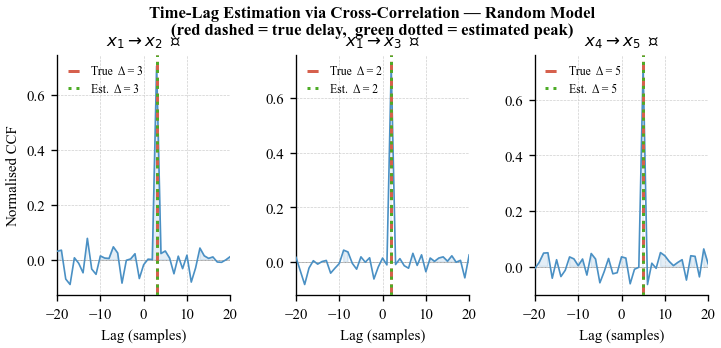

In [ ]:
from scipy.signal import correlate as sp_correlate

# ── True causal delays (samples) ──────────────────────────────────────────────
TRUE_DELAYS = {(0, 1): 3, (0, 2): 2, (3, 4): 5}   # (source, target): true_delay

MAX_LAG = 20    # search window ±samples
sig = signal    # use first epoch: shape (N_NODES, T)

def xcorr_delay(x_src, x_tgt, max_lag=MAX_LAG):
    """Return the lag at which cross-correlation peaks in [1, max_lag]."""
    cc   = sp_correlate(x_tgt, x_src, mode='full')
    cc  /= (np.std(x_src) * np.std(x_tgt) * len(x_src))   # normalise to [-1, 1]
    lags = np.arange(-(len(x_src) - 1), len(x_src))
    # Only look at positive lags (src leads tgt)
    pos  = (lags >= 1) & (lags <= max_lag)
    return int(lags[pos][np.argmax(cc[pos])]), cc, lags

# ── Figure: one panel per true edge ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.6),
                         gridspec_kw={'wspace': 0.38})

for ax, ((src, tgt), true_d) in zip(axes, TRUE_DELAYS.items()):
    est_d, cc, lags = xcorr_delay(sig[src], sig[tgt])

    # Restrict display to ±MAX_LAG
    win = (lags >= -MAX_LAG) & (lags <= MAX_LAG)
    ax.plot(lags[win], cc[win], color='#4a90c4', linewidth=1.0, zorder=3)
    ax.fill_between(lags[win], cc[win], 0,
                    where=(cc[win] > 0), alpha=0.15, color='#4a90c4')
    ax.axhline(0, color='#999999', linewidth=0.5, zorder=1)

    ax.axvline(true_d, color='#d6604d', linewidth=1.8, linestyle='--',
               label=f'True  Δ = {true_d}', zorder=4)
    ax.axvline(est_d,  color='#4dac26', linewidth=1.8, linestyle=':',
               label=f'Est.  Δ = {est_d}',  zorder=4)

    match = '✓' if est_d == true_d else '✗'
    ax.set_title(f'$x_{{{src+1}}} \\to x_{{{tgt+1}}}$  {match}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Lag (samples)', fontsize=9)
    ax.set_xlim(-MAX_LAG, MAX_LAG)
    ax.set_xticks([-20, -10, 0, 10, 20])
    ax.legend(fontsize=7, loc='upper left', handlelength=1.2)
    ax.grid(linestyle='--', linewidth=0.4, color='#cccccc', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Normalised CCF', fontsize=9)

fig.suptitle(
    'Time-Lag Estimation via Cross-Correlation — Random Model\n'
    '(red dashed = true delay,  green dotted = estimated peak)',
    fontsize=10, fontweight='bold', y=1.04
)
plt.tight_layout()
savefig('fig5_lag_estimation')
plt.show()

## 5. Frequency-Domain Profiles (PDCoh & DTF, non-integrated)

Computing Extended Infomax ICA
Computing Extended Infomax ICA
Saved → figures/fig6_pdcoh_freq_profile.pdf / .png


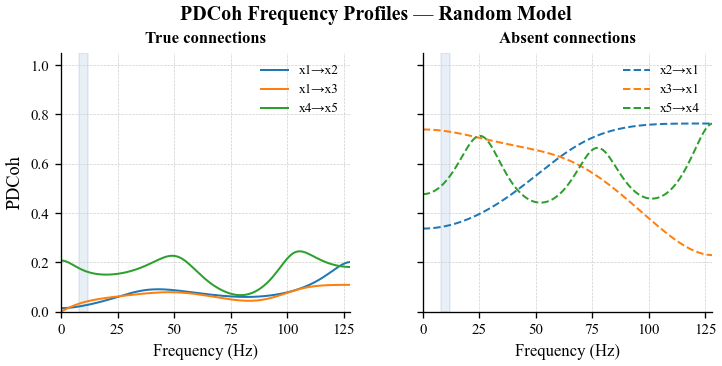

Saved → figures/fig6_dtf_freq_profile.pdf / .png


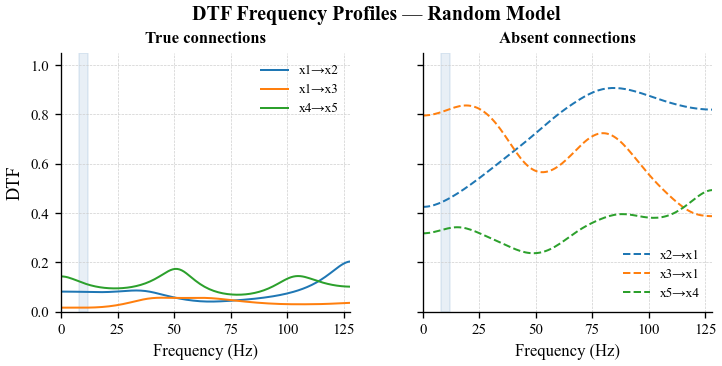

In [ ]:
# Recompute PDCoh and DTF without frequency integration
res_freq = FCMethods(epochs, fs=FS).compute_all({
    'PDCoh': {'model_order': 5, 'n_fft': 128,
              'ica_method': 'infomax_extended', 'integrate': False},
    'DTF'  : {'model_order': 5, 'n_fft': 128,
              'ica_method': 'infomax_extended', 'integrate': False},
})

TRUE_EDGES   = [(0,1), (0,2), (3,4)]   # ground truth
ABSENT_EDGES = [(1,0), (2,0), (4,3)]   # reversed — should be near zero

for method in ('PDCoh', 'DTF'):
    mat   = res_freq[method]['matrix']              # shape: (n, n, n_fft)
    freqs = np.linspace(0, FS / 2, mat.shape[2])   # Hz

    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8),
                             sharey=True,
                             gridspec_kw={'wspace': 0.25})

    # Panel A: true connections
    for (s, t) in TRUE_EDGES:
        axes[0].plot(freqs, mat[s, t, :],
                     label=f'{NODE_LABELS[s]}→{NODE_LABELS[t]}')
    axes[0].set_title('True connections', fontsize=10, fontweight='bold')
    axes[0].legend(fontsize=8)

    # Panel B: absent / reversed connections
    for (s, t) in ABSENT_EDGES:
        axes[1].plot(freqs, mat[s, t, :], linestyle='--',
                     label=f'{NODE_LABELS[s]}→{NODE_LABELS[t]}')
    axes[1].set_title('Absent connections', fontsize=10, fontweight='bold')
    axes[1].legend(fontsize=8)

    for ax in axes:
        ax.set_xlabel('Frequency (Hz)', fontsize=10)
        ax.set_xlim(0, FS / 2)
        ax.set_ylim(0, 1.05)
        ax.axvspan(8, 12, alpha=0.10, color='#2166ac', label='Alpha band')
        ax.grid(linestyle='--', linewidth=0.4, color='#cccccc')

    axes[0].set_ylabel(method, fontsize=11)

    fig.suptitle(f'{method} Frequency Profiles — Random Model',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    savefig(f'fig6_{method.lower()}_freq_profile')
    plt.show()